In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    cohen_kappa_score, make_scorer,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from pathlib import Path


import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42

DATA_PATH = Path("data") / "TVSEP2024_HHQ_V3VN.dta"
TARGET = "v31313a"


In [2]:
# ----------------------------------------------------------------------
# Load dataset
# ----------------------------------------------------------------------
df = pd.read_stata(DATA_PATH, convert_categoricals=False)

reader = pd.io.stata.StataReader(DATA_PATH)
VAR_LABELS = reader.variable_labels()
VALUE_LABELS = reader.value_labels()

print(f"Dataset shape: {df.shape}")
print(f"Number of variables with variable labels: {len(VAR_LABELS)}")
print(f"Sample variable labels:")
for c in ["v31313a", "v81045a", "v31410", "v31412"]:
    if c in VAR_LABELS:
        print(f"  {c}: {VAR_LABELS[c]}")
df.head()


Dataset shape: (2198, 970)
Number of variables with variable labels: 970
Sample variable labels:
  v31313a: Do you think your HH is better off than last year?
  v81045a: Average expenditure on health for the whole HH in ref. period (THB/1000 VND)
  v31410: Aspiration of annual income level
  v31412: Aspiration of asset level


,interview__key,interview__id,QID,v10000,agreement,v10008,v10008TH,v10001,v10002,v10003,...,v93001e,v93001f,v93001g,v93001h,v93001i,v93001j,v93001k,v93001l,v93002,v10009
0,00-00-65-79,10e3c3d4f4a94de49e6f370394ac685f,4.051113e+10,2,1,2024-11-15T13:42:43,2567-11-15T13:42:43,405,40511,4051113,...,8,10,8,10,8,8,10,7,9,2024-11-15T17:46:48
1,00-02-55-51,ea61098a4bdd49fbb5358707627f7191,6.052303e+10,2,1,2024-11-01T08:10:08,2567-11-01T08:10:08,605,60523,6052303,...,7,5,2,7,7,6,5,5,6,2024-11-01T10:53:58
2,00-02-80-42,a708bebed4f749cb914b9b6072b4fd97,4.110923e+10,2,1,2024-12-14T13:44:50,2567-12-14T13:44:50,411,41109,4110923,...,10,10,6,10,6,7,10,7,6,2024-12-14T15:51:52
3,00-04-67-68,3a3a62e70c6f4021bbb08b2fdbdbe214,4.051549e+10,2,1,2024-11-19T08:20:56,2567-11-19T08:20:56,405,40515,4051549,...,8,7,8,9,8,9,7,9,8,2024-11-19T11:38:45
4,00-06-18-45,d2b36bfe277244549c95218ffe533b2a,4.051735e+10,2,1,2024-11-20T08:12:22,2567-11-20T08:12:22,405,40517,4051735,...,8,7,7,8,8,8,5,8,8,2024-11-20T11:04:26


In [3]:
# ----------------------------------------------------------------------
# Analysis target variable v31313a
# ----------------------------------------------------------------------
print(f"Target variable: {TARGET}")
print(f"Question: {VAR_LABELS.get(TARGET, '')}")
print(f"\nDtype: {df[TARGET].dtype}")
print(f"\nValue counts:")
print(df[TARGET].value_counts().sort_index())

target_value_map = VALUE_LABELS.get(TARGET, {})
if target_value_map:
    print(f"\nValue labels:")
    for k, v in sorted(target_value_map.items()):
        print(f"  {k} = {v}")


Target variable: v31313a
Question: Do you think your HH is better off than last year?

Dtype: int8

Value counts:
v31313a
1      37
2     653
3    1154
4     331
5      23
Name: count, dtype: int64

Value labels:
  1 = Much better off
  2 = Better off
  3 = Same
  4 = Worse off
  5 = Much worse off
  98 = No answer


Affter drop missing target: 2198 household (drop 0 household)


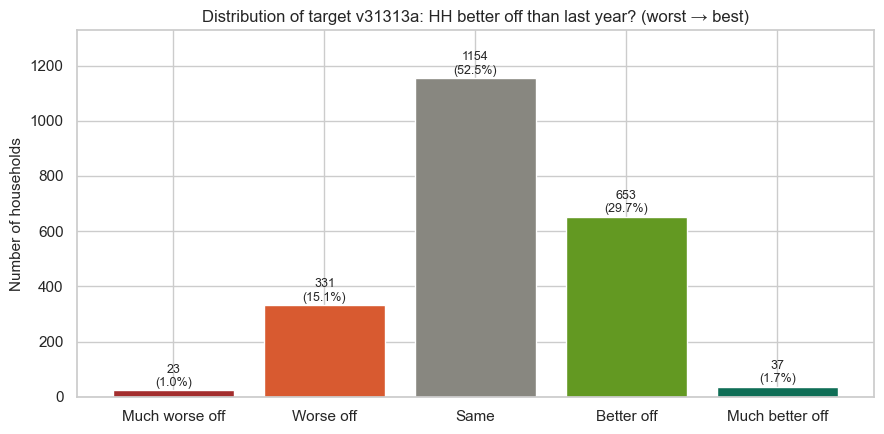


⚠️  Class imbalance ratio (max/min): 50x


In [4]:
# ----------------------------------------------------------------------
# Picture 1: Distribution of target (5 level)
# ----------------------------------------------------------------------
df_clean = df.dropna(subset=[TARGET]).copy()
print(f"Affter drop missing target: {df_clean.shape[0]} household (drop {df.shape[0]-df_clean.shape[0]} household)")


# Stata code 1=Much better, 5=Much worse → to display "worst → best"
# We reverse the order (Stata 5 displays first, Stata 1 displays last).
target_counts = df_clean[TARGET].value_counts().sort_index(ascending=False)
target_pct = df_clean[TARGET].value_counts(normalize=True).sort_index(ascending=False) * 100

labels_ordered = [target_value_map.get(int(k), str(k)) for k in target_counts.index]

colors_ordinal = ["#A32D2D", "#D85A30", "#888780", "#639922", "#0F6E56"]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(labels_ordered, target_counts.values, color=colors_ordinal[:len(labels_ordered)])
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f"{int(count)}\n({pct:.1f}%)", ha="center", fontsize=9)
ax.set_ylabel("Number of households")
ax.set_title("Distribution of target v31313a: HH better off than last year? (worst → best)")
ax.set_ylim(0, target_counts.max() * 1.15)
plt.tight_layout()
plt.savefig("fig01_target_distribution.png", bbox_inches="tight")
plt.show()

print(f"\n⚠️  Class imbalance ratio (max/min): {target_counts.max()/target_counts.min():.0f}x")


In [5]:
# ----------------------------------------------------------------------
# DATA CLEANING - DATA LEAKAGE
# ----------------------------------------------------------------------
# 1. LEAKAGE VARIABLES — Variables with the same concept as the target. → MUST DROP:
LEAKAGE_VARS = [
    "v31313b",            # Same question but for an individual (almost a copy of the target).
    "v31314a", "v31314b", # Same Q but compared to 5 years ago
    "v31317", "v31318",   # Best/worst year in last 5 years
    "v31319a", "v31319b", # Future expectation 1 year
    "v31320a", "v31320b", # Future expectation 5 years
    "v91005", "v91006",   # Self-comparison with other HH (proxy of well-being)
]

# 2. SUBJECTIVE SATISFACTION — debatable, should be excluded to avoid bias:
SUBJECTIVE_VARS = [c for c in df.columns
                   if c.startswith("v93001") or c == "v93002"]

# 3. ID / ADMIN VARIABLES — no predictive value, only causes overfitting:
ID_VARS = []
for c in df.columns:
    if c in {"QID", "HID"}:
        ID_VARS.append(c)
    elif c.startswith("v1000") and len(c) <= 6:
        ID_VARS.append(c)
    elif c.startswith("v100") and c[4:].rstrip("ab").isdigit() and 0 < int(c[4:].rstrip("ab")) < 25:
        ID_VARS.append(c)

ID_VARS = sorted(set(ID_VARS))

print(f"The variable LEAKAGE was removed. ({len(LEAKAGE_VARS)}):")
for v in LEAKAGE_VARS:
    if v in df.columns:
        print(f"  - {v}: {VAR_LABELS.get(v, '')}")

print(f"\nThe variable SUBJECTIVE was removed. ({len(SUBJECTIVE_VARS)}):")
for v in SUBJECTIVE_VARS[:5]:
    print(f"  - {v}: {VAR_LABELS.get(v, '')}")
print(f"  ... (tổng {len(SUBJECTIVE_VARS)} biến)")

print(f"\nThe ID variable is eliminated ({len(ID_VARS)}): {ID_VARS[:8]}...")


The variable LEAKAGE was removed. (11):
  - v31313b: Do you think you in person are better off than last year?
  - v31314a: Do you think your household is better off than 5 years ago?
  - v31314b: Do you think you in person are better off than 5 years ago?
  - v31317: Which was the best year for your household in the last 5 years?
  - v31318: Which was the worst year for your household in the last 5 years?
  - v31319a: Do you think your household will be better off next year?
  - v31319b: Do you think you in person will be better off next year?
  - v31320a: Do you think your household will be better off in 5 years?
  - v31320b: Do you think you in person will be better off in 5 years?
  - v91005: How well-off do you consider your HH in comparison to other residents - Village
  - v91006: How well-off do you consider your HH in comparison to other residents - country

The variable SUBJECTIVE was removed. (13):
  - v93001a: How satisfied are you with your education?
  - v93001b: How satis

In [6]:
# ----------------------------------------------------------------------
# Create X (features) and Y (target)
# ----------------------------------------------------------------------
DROP_VARS = list(set(LEAKAGE_VARS + SUBJECTIVE_VARS + ID_VARS + [TARGET]))
DROP_VARS = [c for c in DROP_VARS if c in df_clean.columns]

df_work = df_clean.copy()
for col in df_work.columns:
    if col != TARGET:
        df_work[col] = pd.to_numeric(df_work[col], errors="coerce")

X_full = df_work.drop(columns=DROP_VARS)

nan_pct = X_full.isna().mean()
high_nan_cols = nan_pct[nan_pct > 0.5].index.tolist()
print(f"Drop {len(high_nan_cols)} column have >50% missing")
X_full = X_full.drop(columns=high_nan_cols)

nunique = X_full.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
if constant_cols:
    print(f"Drop {len(constant_cols)} column constant: {constant_cols[:5]}...")
    X_full = X_full.drop(columns=constant_cols)

print(f"\nFinal X shape: {X_full.shape}")
print(f"y shape: {df_work[TARGET].shape}")


Drop 367 column have >50% missing
Drop 39 column constant: ['agreement', 'v31102__81', 'v31102__98', 'v32025__98', 'v32030__8']...

Final X shape: (2198, 504)
y shape: (2198,)


In [7]:
# ----------------------------------------------------------------------
# Y target — REVERSE inorder to 0=WORST, 4=BEST (intuitive thesis report)
# ----------------------------------------------------------------------
# Stata code of v31313a:
#   1 = Much better off (BEST)        ← 37 household
#   2 = Better off                    ← 653 household
#   3 = Same                          ← 1154 household
#   4 = Worse off                     ← 331 household
#   5 = Much worse off (WORST)        ← 23 household

y_raw = df_work[TARGET].astype(int).values
y = 5 - y_raw

CLASS_NAMES = [target_value_map[5-i] for i in range(5)]

print("Class mapping (REVERSED — 0=worst → 4=best):")
for i, name in enumerate(CLASS_NAMES):
    count = (y == i).sum()
    print(f"  {i} = {name:20s}  ({count} household, {count/len(y)*100:.1f}%)")


Class mapping (REVERSED — 0=worst → 4=best):
  0 = Much worse off        (23 household, 1.0%)
  1 = Worse off             (331 household, 15.1%)
  2 = Same                  (1154 household, 52.5%)
  3 = Better off            (653 household, 29.7%)
  4 = Much better off       (37 household, 1.7%)


In [8]:
# ----------------------------------------------------------------------
# Train/Test split — BEFORE feature selection (to avoid data leakage)
# ----------------------------------------------------------------------

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f"Train shape: {X_train_full.shape}")
print(f"Test shape:  {X_test_full.shape}")
print(f"\nTrain class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index().round(3))


Train shape: (1758, 504)
Test shape:  (440, 504)

Train class distribution:
0    0.010
1    0.151
2    0.525
3    0.297
4    0.017
Name: proportion, dtype: float64


In [9]:
# ----------------------------------------------------------------------
# Feature Selection by Random Forest Importance
# ----------------------------------------------------------------------
imputer_fs = SimpleImputer(strategy="median")
X_train_imp = imputer_fs.fit_transform(X_train_full)

rf_selector = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)
rf_selector.fit(X_train_imp, y_train)

importance_df = pd.DataFrame({
    "Feature": X_train_full.columns,
    "Importance": rf_selector.feature_importances_,
    "Label": [VAR_LABELS.get(c, "")[:60] for c in X_train_full.columns],
}).sort_values("Importance", ascending=False).reset_index(drop=True)

TOP_K = 50
top_features = importance_df.head(TOP_K)["Feature"].tolist()

print(f"Selected top {TOP_K} features from TRAIN SET (no leak):")
print(importance_df.head(15).to_string(index=False))


Selected top 50 features from TRAIN SET (no leak):
  Feature  Importance                                                        Label
  v81045a    0.023453 Average expenditure on health for the whole HH in ref. perio
  v42040a    0.017298        Amount of fertilizer used: mineral fertilizer (in kg)
   v42023    0.016173              Expenditures: mineral fertilizer (THB/1000 VND)
  v42042f    0.014548    Labor: Family labor (Person hour) for applying pesticides
  v81030a    0.013890 Average monthly expenditure on transport/com for the whole H
   v31410    0.013866                            Aspiration of annual income level
   v31414    0.013177                            Aspiration of social status level
   v31412    0.012977                                    Aspiration of asset level
  v42041f    0.012872                   Family labor (Person hour) for fertilizing
v82001__1    0.012757 Food insecurity experience:… was there a time when you were 
   v31328    0.012482               

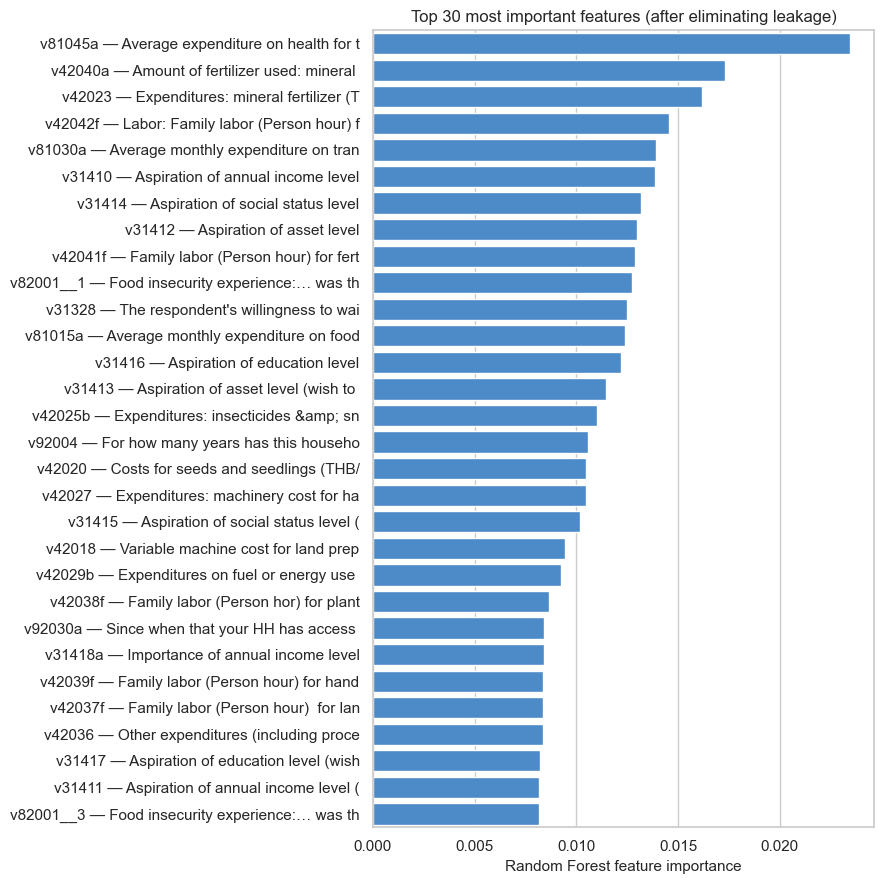

In [10]:
# ----------------------------------------------------------------------
# Figure 3: Top 30 feature importance from RF (initial selection)
# ----------------------------------------------------------------------
top30 = importance_df.head(30).copy()
top30["DisplayName"] = top30.apply(
    lambda r: f"{r['Feature']} — {r['Label'][:35]}", axis=1
)

fig, ax = plt.subplots(figsize=(9, 9))
sns.barplot(data=top30, x="Importance", y="DisplayName",
            color="#378ADD", ax=ax)
ax.set_xlabel("Random Forest feature importance")
ax.set_ylabel("")
ax.set_title("Top 30 most important features (after eliminating leakage)")
plt.tight_layout()
plt.savefig("fig03_rf_feature_importance.png", bbox_inches="tight")
plt.show()


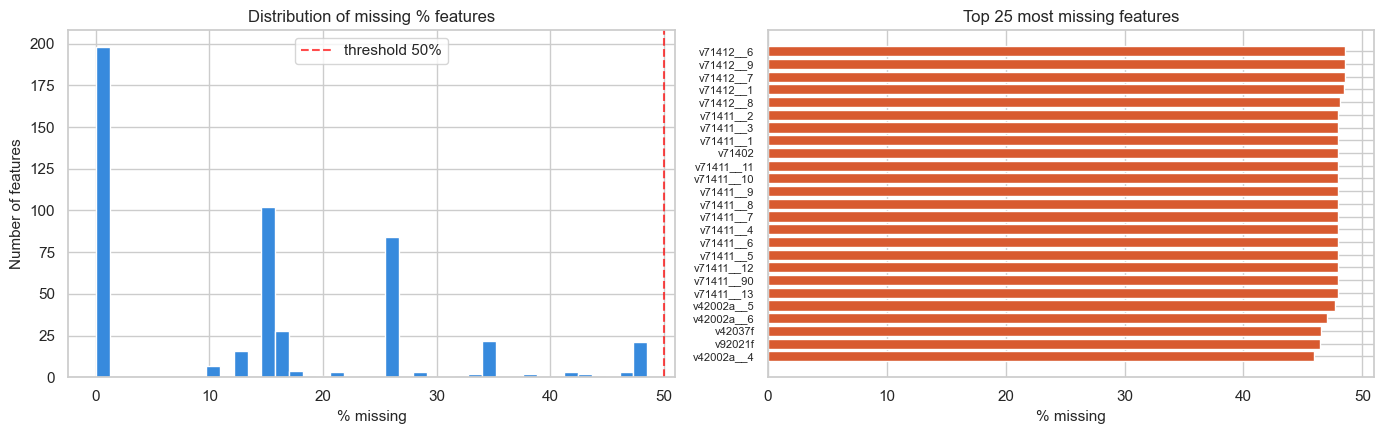

Average % missing: 14.0%
The number of features is completely complete: 183


In [11]:
# ----------------------------------------------------------------------
# Figure 2: Level of missing features
# ----------------------------------------------------------------------
nan_pct = X_full.isna().mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Histogram distribution missing %
axes[0].hist(nan_pct.values * 100, bins=40, color="#378ADD", edgecolor="white")
axes[0].set_xlabel("% missing")
axes[0].set_ylabel("Number of features")
axes[0].set_title("Distribution of missing % features")
axes[0].axvline(50, color="red", linestyle="--", alpha=0.7, label="threshold 50%")
axes[0].legend()

# Top 25 most frequently missing columns
top_nan = nan_pct.head(25)
axes[1].barh(range(len(top_nan)), top_nan.values * 100, color="#D85A30")
axes[1].set_yticks(range(len(top_nan)))
axes[1].set_yticklabels(top_nan.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("% missing")
axes[1].set_title("Top 25 most missing features")

plt.tight_layout()
plt.savefig("fig02_missingness.png", bbox_inches="tight")
plt.show()

print(f"Average % missing: {nan_pct.mean()*100:.1f}%")
print(f"The number of features is completely complete: {(nan_pct == 0).sum()}")


In [12]:
# ----------------------------------------------------------------------
# The table describes the features.
# ----------------------------------------------------------------------
summary = X_full.describe().T
summary["missing_pct"] = X_full.isna().mean() * 100
summary["n_unique"] = X_full.nunique()

summary = summary.sort_values("std", ascending=False)

print("Top 15 variables with the highest variability:")
display_cols = ["mean", "std", "min", "50%", "max", "missing_pct", "n_unique"]
print(summary[display_cols].head(15).round(2))


Top 15 variables with the highest variability:
             mean       std   min      50%       max  missing_pct  n_unique
v81039a  13195.12  31687.44 -99.0      0.0  450000.0         0.59       389
v42023   10041.93  23684.54  20.0   4000.0  720000.0        21.88       432
v31325   23483.63  22308.66   0.0  30000.0   60000.0         0.14        42
v81045a   8577.65  21155.31   0.0   3000.0  400000.0         0.05       316
v42025b   2371.12   6062.82   0.0    500.0   80000.0        33.26       171
v42020    2167.56   4596.61   0.0    900.0   80000.0        16.29       387
v42029b   1337.52   3318.42   0.0     50.0   45000.0        17.02       192
v42018    2003.35   3009.25   0.0   1200.0   35683.0        37.90       238
v42036     653.88   2711.25   0.0    145.0   74000.0        16.29       190
v81015a   3945.67   2664.89   0.0   3210.0   30000.0         0.00       357
v42027     968.12   1876.52   0.0    385.0   23500.0        16.29       222
v81030a   1261.02   1773.65   0.0    800.

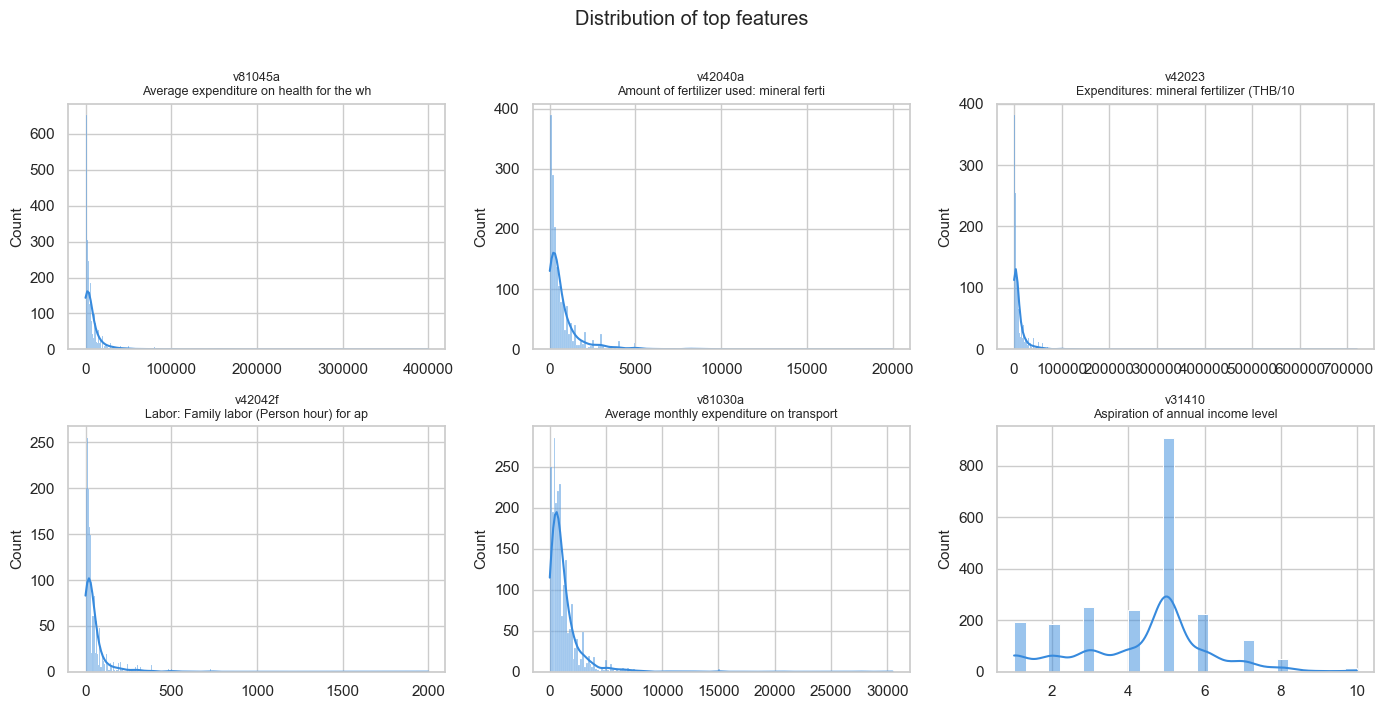

In [13]:
# ----------------------------------------------------------------------
# Figure 4: Distribution of the top 6 features (histogram + KDE)
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flatten(), top_features[:6]):
    s = df_work[feat].dropna()
    sns.histplot(s, kde=True, ax=ax, color="#378ADD", edgecolor="white")
    label = VAR_LABELS.get(feat, "")[:40]
    ax.set_title(f"{feat}\n{label}", fontsize=9)
    ax.set_xlabel("")
plt.suptitle("Distribution of top features", y=1.01)
plt.tight_layout()
plt.savefig("fig04_distributions.png", bbox_inches="tight")
plt.show()


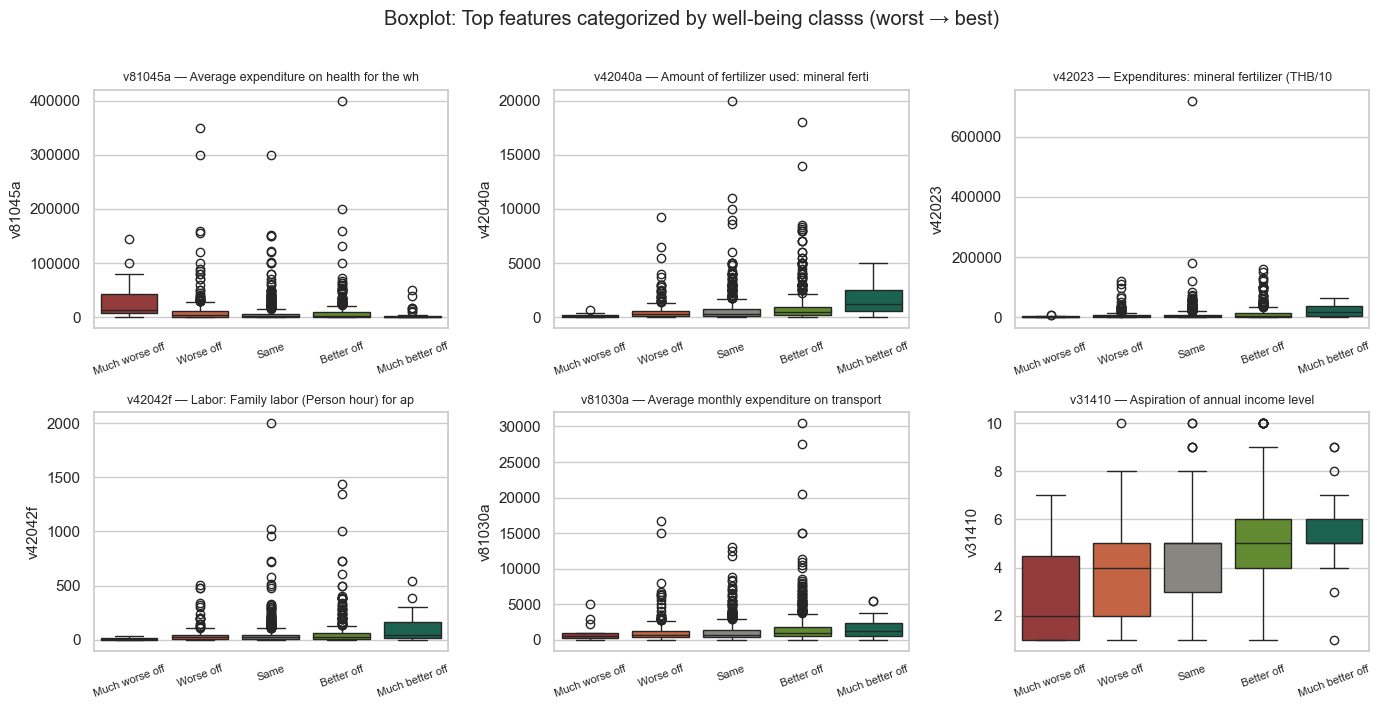

In [14]:
# ----------------------------------------------------------------------
# Figure 5: Boxplot top features by target class
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
df_plot = df_work.copy()
df_plot["_target_"] = df_work[TARGET].astype(int)
df_plot["_target_label_"] = df_plot["_target_"].map(target_value_map)

order_labels = [target_value_map[5-i] for i in range(5)]
ordinal_palette = ["#A32D2D", "#D85A30", "#888780", "#639922", "#0F6E56"]

for ax, feat in zip(axes.flatten(), top_features[:6]):
    sns.boxplot(data=df_plot, x="_target_label_", y=feat, ax=ax,
                order=order_labels, palette=ordinal_palette)
    label = VAR_LABELS.get(feat, "")[:40]
    ax.set_title(f"{feat} — {label}", fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20, labelsize=8)
plt.suptitle("Boxplot: Top features categorized by well-being classs (worst → best)", y=1.01)
plt.tight_layout()
plt.savefig("fig05_boxplots.png", bbox_inches="tight")
plt.show()


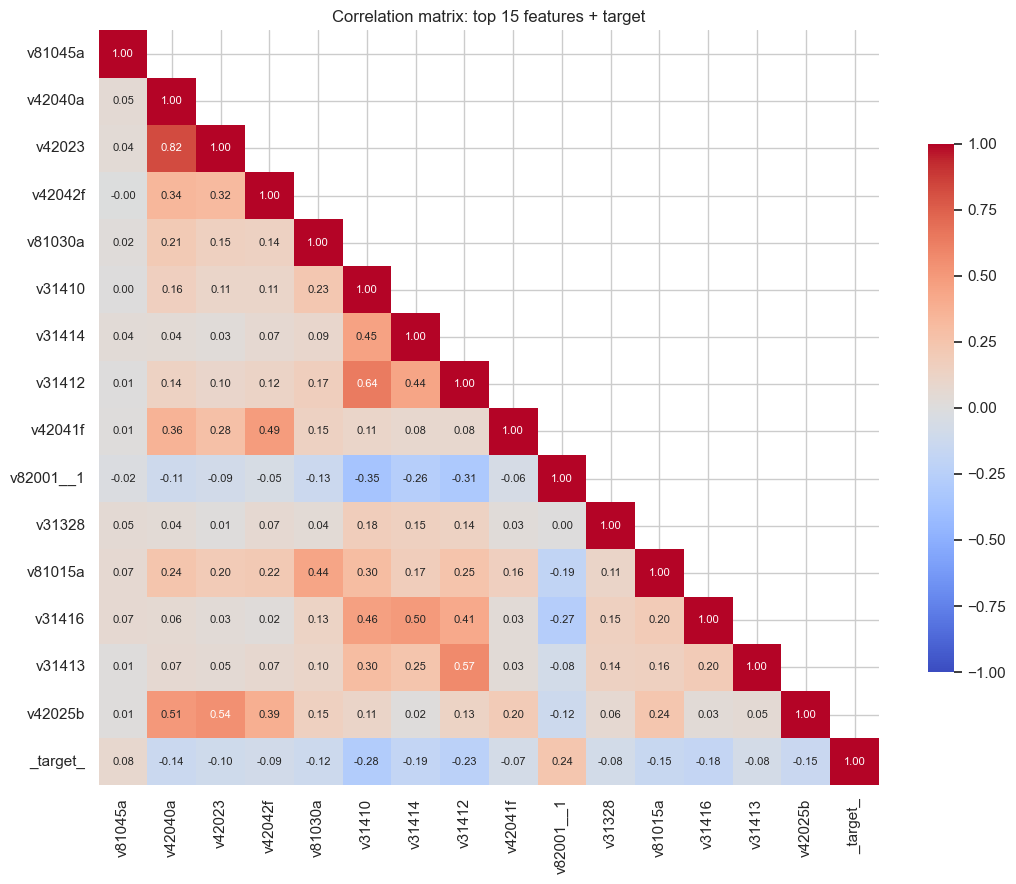


⚠️  The pair of features are highly correlated (|r| > 0.7) — can cause multicollinearity:
  v42040a ↔ v42023: r = 0.822


In [15]:
# ----------------------------------------------------------------------
# Figure 6: Correlation heatmap of the top 15 features + target
# ----------------------------------------------------------------------
top15 = top_features[:15]
corr_data = df_work[top15].copy()
corr_data["_target_"] = df_work[TARGET].astype(int)

corr_matrix = corr_data.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, mask=mask,
            cbar_kws={"shrink": 0.7}, ax=ax,
            annot_kws={"fontsize": 8})
ax.set_title("Correlation matrix: top 15 features + target")
plt.tight_layout()
plt.savefig("fig06_correlation_matrix.png", bbox_inches="tight")
plt.show()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))

if high_corr_pairs:
    print("\n⚠️  The pair of features are highly correlated (|r| > 0.7) — can cause multicollinearity:")
    for a, b, r in high_corr_pairs:
        print(f"  {a} ↔ {b}: r = {r:.3f}")
else:
    print("\n✓ No pairs of features are highly correlated.")


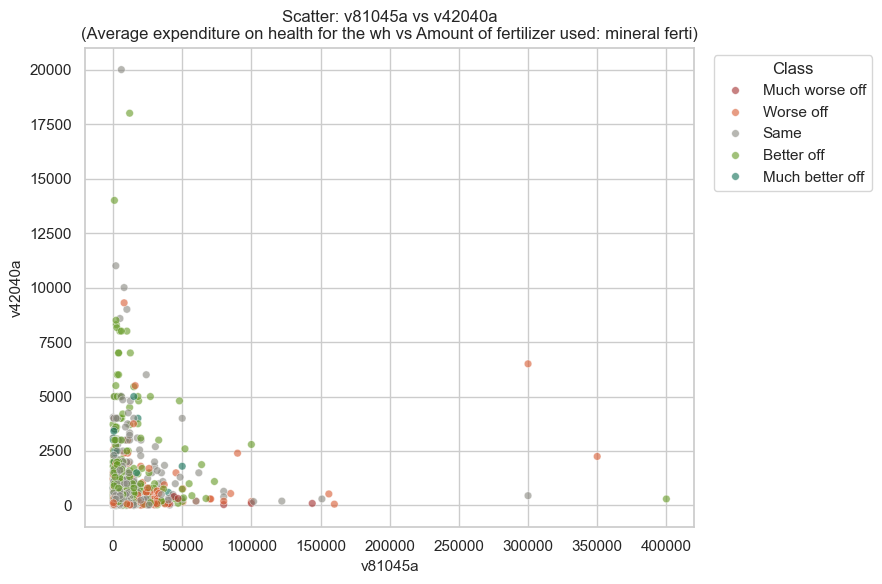

In [16]:
# ----------------------------------------------------------------------
# Figure 7: Scatter plot showing the two most important features by class
# ----------------------------------------------------------------------
df_scatter = df_work.copy()
df_scatter["_target_"] = df_work[TARGET].astype(int)
df_scatter["_class_"] = df_scatter["_target_"].map(target_value_map)

hue_order = [target_value_map[5-i] for i in range(5)]
ordinal_palette = ["#A32D2D", "#D85A30", "#888780", "#639922", "#0F6E56"]

f1, f2 = top_features[0], top_features[1]
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=df_scatter, x=f1, y=f2, hue="_class_",
    hue_order=hue_order, palette=ordinal_palette,
    alpha=0.6, s=30, ax=ax,
)
ax.set_title(f"Scatter: {f1} vs {f2}\n"
             f"({VAR_LABELS.get(f1, '')[:40]} vs {VAR_LABELS.get(f2, '')[:40]})")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("fig07_scatter.png", bbox_inches="tight")
plt.show()


In [17]:
# ----------------------------------------------------------------------
# Build preprocessing pipeline
# ----------------------------------------------------------------------
preprocessor = ColumnTransformer([
    ("num", SklearnPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), top_features),
])

X_train = X_train_full[top_features]
X_test = X_test_full[top_features]

print(f"Features used for models: {len(top_features)}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Features used for models: 50
Train: (1758, 50), Test: (440, 50)


In [18]:
# ----------------------------------------------------------------------
# Cross-validation of 3 models with suitable scoring.
# ----------------------------------------------------------------------
# Quadratic Weighted Kappa (QWK) là metric ORDINAL-AWARE:
# - A one-level misclassification (Same → Better) will result in a minor penalty.
# - A four-level misclassification (Much worse → Much better) will result in a major penalty.
qwk_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "qwk": qwk_scorer,            # ⭐ ordinal-aware
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced",
        solver="lbfgs", random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, max_depth=10, min_samples_leaf=5,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", num_class=len(np.unique(y)),
        eval_metric="mlogloss", random_state=RANDOM_STATE,
    ),
}

results = []
for name, mdl in models.items():
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ("model", mdl),
    ])
    sc = cross_validate(pipe, X_train, y_train, cv=cv,
                        scoring=scoring, n_jobs=-1)
    results.append({
        "Model": name,
        "Accuracy": f"{sc['test_accuracy'].mean():.3f} ± {sc['test_accuracy'].std():.3f}",
        "F1-macro": f"{sc['test_f1_macro'].mean():.3f} ± {sc['test_f1_macro'].std():.3f}",
        "QWK ⭐":   f"{sc['test_qwk'].mean():.3f} ± {sc['test_qwk'].std():.3f}",
        "_acc_mean": sc["test_accuracy"].mean(),
        "_f1_mean":  sc["test_f1_macro"].mean(),
        "_qwk_mean": sc["test_qwk"].mean(),
    })

results_df = pd.DataFrame(results)
print("RESULTS OF 5-FOLD CV ON TRAIN SET:")
print(results_df[["Model", "Accuracy", "F1-macro", "QWK ⭐"]].to_string(index=False))

baseline_acc = pd.Series(y_train).value_counts(normalize=True).max()
print(f"\nBaseline accuracy (predicting the majority class): {baseline_acc:.3f}")


RESULTS OF 5-FOLD CV ON TRAIN SET:
              Model      Accuracy      F1-macro         QWK ⭐
Logistic Regression 0.385 ± 0.019 0.294 ± 0.011 0.251 ± 0.043
      Random Forest 0.517 ± 0.040 0.299 ± 0.037 0.308 ± 0.055
            XGBoost 0.517 ± 0.024 0.290 ± 0.048 0.216 ± 0.070

Baseline accuracy (predicting the majority class): 0.525


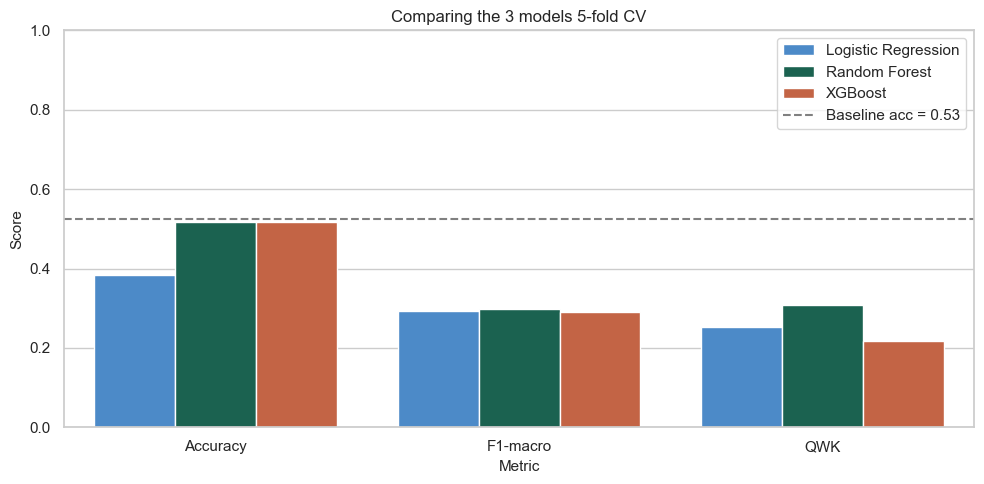

In [19]:
# ----------------------------------------------------------------------
# Figure 8: Comparison of models across metrics
# ----------------------------------------------------------------------
plot_df = results_df[["Model", "_acc_mean", "_f1_mean", "_qwk_mean"]].copy()
plot_df.columns = ["Model", "Accuracy", "F1-macro", "QWK"]
melted = plot_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=melted, x="Metric", y="Score", hue="Model",
            palette=["#378ADD", "#0F6E56", "#D85A30"], ax=ax)
ax.axhline(baseline_acc, color="gray", linestyle="--",
           label=f"Baseline acc = {baseline_acc:.2f}")
ax.set_ylim(0, 1)
ax.set_title("Comparing the 3 models 5-fold CV")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("fig08_model_comparison.png", bbox_inches="tight")
plt.show()


In [20]:
# ----------------------------------------------------------------------
# Train the final model on TRAIN, evaluate it on TEST.
# ----------------------------------------------------------------------
final_model = Pipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ("model", XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", num_class=len(np.unique(y)),
        eval_metric="mlogloss", random_state=RANDOM_STATE,
    )),
])
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

print("=" * 60)
print("RESULTS ON TEST SET:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"F1-macro: {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"QWK ⭐:   {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.3f}")


RESULTS ON TEST SET:
                 precision    recall  f1-score   support

 Much worse off       0.00      0.00      0.00         5
      Worse off       0.29      0.17      0.21        66
           Same       0.57      0.71      0.63       231
     Better off       0.44      0.37      0.40       131
Much better off       0.00      0.00      0.00         7

       accuracy                           0.51       440
      macro avg       0.26      0.25      0.25       440
   weighted avg       0.47      0.51      0.48       440

Accuracy: 0.509
F1-macro: 0.249
QWK ⭐:   0.231


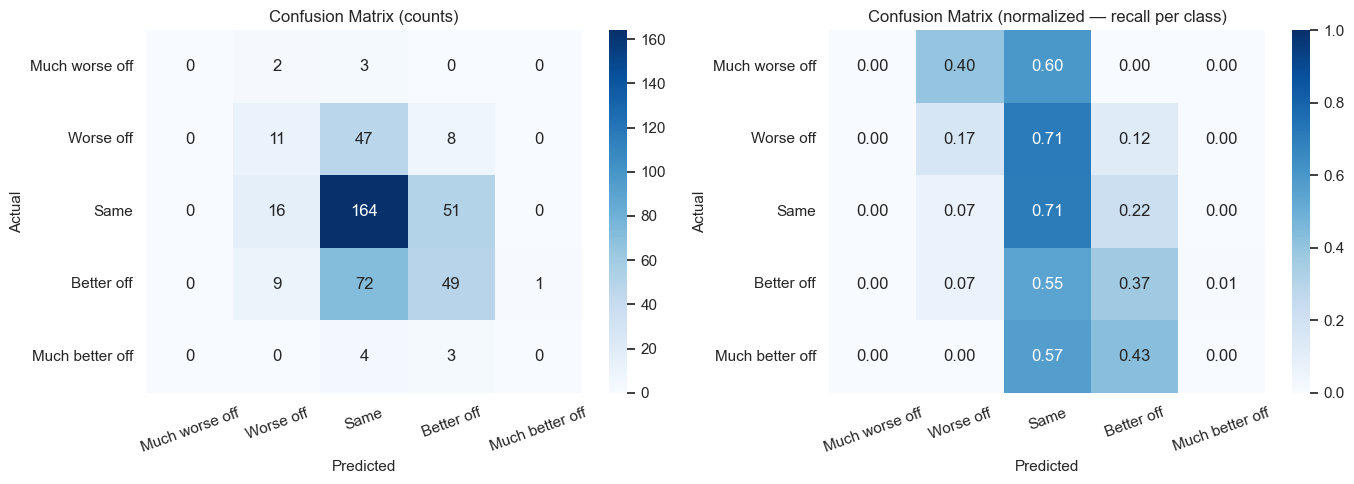

In [21]:
# ----------------------------------------------------------------------
# Figure 9: Confusion matrix
# ----------------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].tick_params(axis="x", rotation=20)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix (normalized — recall per class)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("fig09_confusion_matrix.png", bbox_inches="tight")
plt.show()


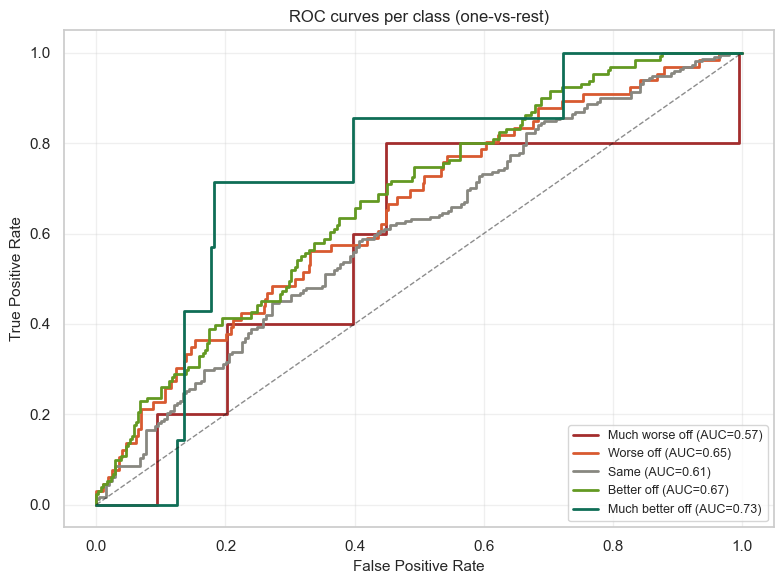

In [22]:
# ----------------------------------------------------------------------
# Figure 10: ROC curve per-class (one-vs-rest) — multiclass
# ----------------------------------------------------------------------
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=list(range(5)))
n_classes = y_test_bin.shape[1]

fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ["#A32D2D", "#D85A30", "#888780", "#639922", "#0F6E56"]

for i, color, name in zip(range(n_classes), colors_roc, CLASS_NAMES):
    if y_test_bin[:, i].sum() == 0:
        continue
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    ax.plot(fpr_i, tpr_i, color=color, lw=2,
            label=f"{name} (AUC={auc_i:.2f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves per class (one-vs-rest)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig10_roc_multiclass.png", bbox_inches="tight")
plt.show()


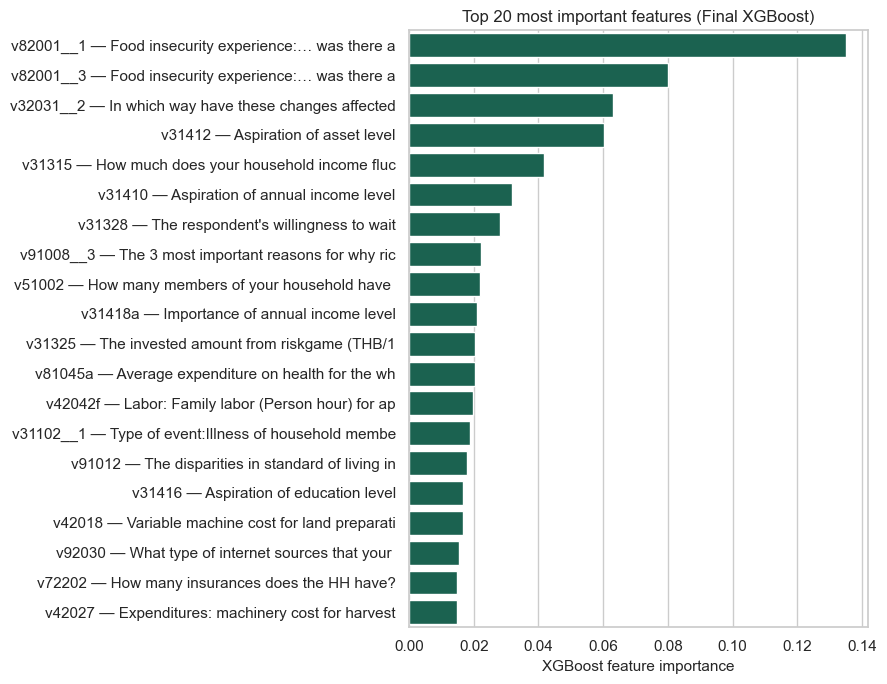

Top 20 features:
  Feature  Importance                                    Label
v82001__1    0.135051 Food insecurity experience:… was there a
v82001__3    0.080091 Food insecurity experience:… was there a
v32031__2    0.063000 In which way have these changes affected
   v31412    0.060346                Aspiration of asset level
   v31315    0.041701 How much does your household income fluc
   v31410    0.031867        Aspiration of annual income level
   v31328    0.028149     The respondent's willingness to wait
v91008__3    0.022248 The 3 most important reasons for why ric
   v51002    0.021850 How many members of your household have 
  v31418a    0.021133        Importance of annual income level
   v31325    0.020328 The invested amount from riskgame (THB/1
  v81045a    0.020261 Average expenditure on health for the wh
  v42042f    0.019857 Labor: Family labor (Person hour) for ap
v31102__1    0.019000 Type of event:Illness of household membe
   v91012    0.018037 The disparities 

In [23]:
# ----------------------------------------------------------------------
# Figure 11: Feature importance from FINAL XGBoost
# ----------------------------------------------------------------------
xgb_model = final_model.named_steps["model"]
final_imp = pd.DataFrame({
    "Feature": top_features,
    "Importance": xgb_model.feature_importances_,
    "Label": [VAR_LABELS.get(c, "")[:40] for c in top_features],
}).sort_values("Importance", ascending=False).reset_index(drop=True)

top20 = final_imp.head(20).copy()
top20["DisplayName"] = top20.apply(
    lambda r: f"{r['Feature']} — {r['Label']}", axis=1
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=top20, x="Importance", y="DisplayName",
            color="#0F6E56", ax=ax)
ax.set_xlabel("XGBoost feature importance")
ax.set_ylabel("")
ax.set_title("Top 20 most important features (Final XGBoost)")
plt.tight_layout()
plt.savefig("fig11_xgb_importance.png", bbox_inches="tight")
plt.show()

print("Top 20 features:")
print(final_imp.head(20)[["Feature", "Importance", "Label"]].to_string(index=False))


In [24]:
# ----------------------------------------------------------------------
# Feature Count Optimization
# ----------------------------------------------------------------------
# Question: With the best model (XGBoost multiclass), how many features
#           is OPTIMAL? Sweep K from 5 → 200 using the SAME RF importance
#           ranking (importance_df) and run 5-fold CV.
# Primary metric: QWK (ordinal-aware) — same as the main model comparison.
# ----------------------------------------------------------------------
from time import time

K_VALUES = [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 200]
K_VALUES = [k for k in K_VALUES if k <= len(importance_df)]

cv_k = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
qwk_scorer_k = make_scorer(cohen_kappa_score, weights="quadratic")
scoring_k = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "qwk":      qwk_scorer_k,
}

n_classes = len(np.unique(y))
print(f"Sweeping K in {K_VALUES}  (XGBoost multiclass, 5-fold CV)\n")

k_results = []
for k in K_VALUES:
    feats_k = importance_df.head(k)["Feature"].tolist()

    preprocessor_k = ColumnTransformer([
        ("num", SklearnPipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), feats_k),
    ])

    pipe_k = Pipeline([
        ("preprocessing", preprocessor_k),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ("model", XGBClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8,
            objective="multi:softprob", num_class=n_classes,
            eval_metric="mlogloss", random_state=RANDOM_STATE,
        )),
    ])

    t0 = time()
    sc = cross_validate(
        pipe_k, X_train_full[feats_k], y_train,
        cv=cv_k, scoring=scoring_k, n_jobs=-1,
    )
    elapsed = time() - t0

    k_results.append({
        "K": k,
        "Accuracy_mean": sc["test_accuracy"].mean(),
        "Accuracy_std":  sc["test_accuracy"].std(),
        "F1macro_mean":  sc["test_f1_macro"].mean(),
        "F1macro_std":   sc["test_f1_macro"].std(),
        "QWK_mean":      sc["test_qwk"].mean(),
        "QWK_std":       sc["test_qwk"].std(),
        "Fit_time_s":    elapsed,
    })
    print(f"  K={k:3d}  Acc={sc['test_accuracy'].mean():.3f}  "
          f"F1m={sc['test_f1_macro'].mean():.3f}  "
          f"QWK={sc['test_qwk'].mean():.4f}  ({elapsed:.1f}s)")

k_results_df = pd.DataFrame(k_results)

best_idx = k_results_df["QWK_mean"].idxmax()
best_k   = int(k_results_df.loc[best_idx, "K"])
best_qwk = k_results_df.loc[best_idx, "QWK_mean"]
best_qwk_std = k_results_df.loc[best_idx, "QWK_std"]

print(f"\n⭐ Optimal K (by QWK): K = {best_k}  →  QWK = {best_qwk:.4f} ± {best_qwk_std:.4f}")

# Parsimonious — smallest K within 1 SD of best
threshold = best_qwk - best_qwk_std
parsim = k_results_df[k_results_df["QWK_mean"] >= threshold]
parsim_k = int(parsim["K"].min())
parsim_qwk = parsim.loc[parsim["K"] == parsim_k, "QWK_mean"].values[0]
if parsim_k < best_k:
    print(f"💡 Parsimonious K (within 1 SD of best): K = {parsim_k}  →  QWK = {parsim_qwk:.4f}")

print("\nFull table:")
print(k_results_df.round(4).to_string(index=False))


Sweeping K in [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 200]  (XGBoost multiclass, 5-fold CV)



  K=  5  Acc=0.390  F1m=0.227  QWK=0.0991  (3.7s)


  K= 10  Acc=0.462  F1m=0.311  QWK=0.1901  (3.9s)


  K= 15  Acc=0.484  F1m=0.287  QWK=0.2061  (4.5s)


  K= 20  Acc=0.490  F1m=0.279  QWK=0.1976  (2.1s)


...

  K= 75  Acc=0.528  F1m=0.294  QWK=0.2527  (5.0s)


  K=100  Acc=0.522  F1m=0.276  QWK=0.2476  (6.7s)


  K=125  Acc=0.519  F1m=0.274  QWK=0.2326  (8.7s)


  K=150  Acc=0.531  F1m=0.267  QWK=0.2641  (10.9s)


  K=200  Acc=0.525  F1m=0.268  QWK=0.2595  (15.1s)

⭐ Optimal K (by QWK): K = 150  →  QWK = 0.2641 ± 0.0516
💡 Parsimonious K (within 1 SD of best): K = 40  →  QWK = 0.2193

Full table:
  K  Accuracy_mean  Accuracy_std  F1macro_mean  F1macro_std  QWK_mean  QWK_std  Fit_time_s
  5         0.3902        0.0251        0.2270       0.0298    0.0991   0.0582      3.6593
 10         0.4625        0.0044        0.3114       0.0559    0.1901   0.0408      3.9429
 15         0.4841        0.0200        0.2873       0.0522    0.2061   0.0446      4.5403
 20         0.4903        0.0263        0.2792       0.0381    0.1976   0.0554      2.1041
 25         0.4983        0.0239        0.2761       0.0276    0.2042   0.0429      2.3137
 30         0.4920        0.0162        0.2769       0.0543    0.2009   0.0680      2.4059
 40         0.5068        0.0153        0.3061       0.0484    0.2193   0.0701      2.9946
 50         0.5165        0.0239        0.2903       0.0481    0.2165   0.0704      3.5

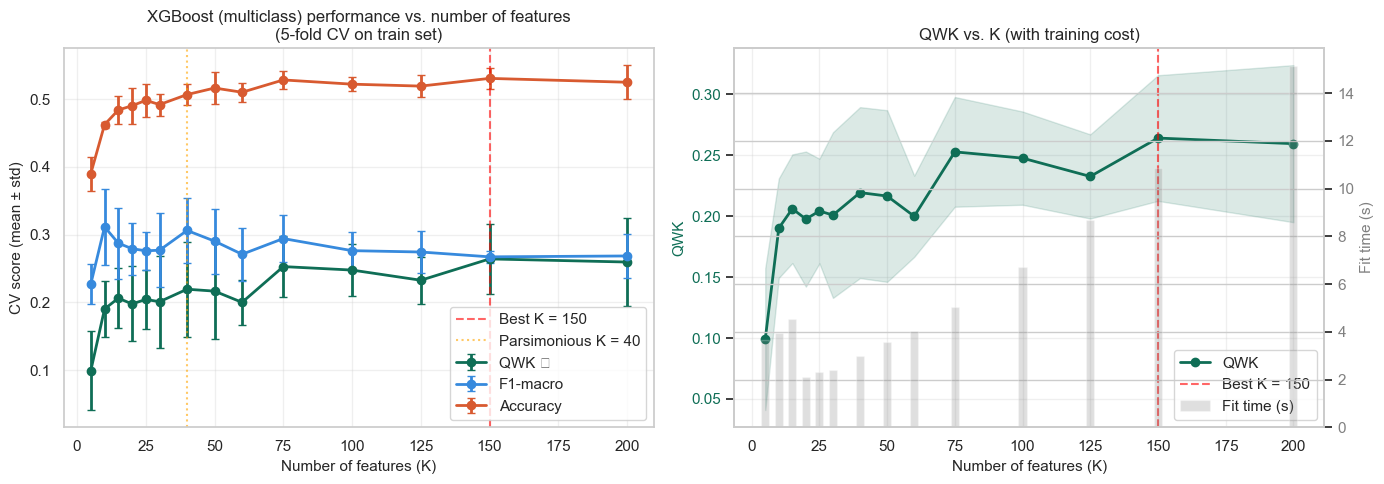

CONCLUSION — Optimal number of features for XGBoost (5-class)
  • Tested K values:    [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 200]
  • Best K (by QWK):    150   (QWK = 0.2641 ± 0.0516)
  • Parsimonious K:     40   (QWK = 0.2193, within 1 SD)
  • Current notebook:   K = 50   (QWK = 0.2165)

  ➜ Recommend updating TOP_K to 150 for QWK gain.


In [25]:
# ----------------------------------------------------------------------
# Figure 12: XGBoost (multiclass) performance vs. number of features (K)
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all 3 metrics
ax = axes[0]
for col, label, color in [
    ("QWK_mean",      "QWK ⭐",     "#0F6E56"),
    ("F1macro_mean",  "F1-macro",   "#378ADD"),
    ("Accuracy_mean", "Accuracy",   "#D85A30"),
]:
    std_col = col.replace("_mean", "_std")
    ax.errorbar(
        k_results_df["K"], k_results_df[col],
        yerr=k_results_df[std_col],
        marker="o", capsize=3, label=label, color=color, linewidth=2,
    )
ax.axvline(best_k, color="red", linestyle="--", alpha=0.6,
           label=f"Best K = {best_k}")
if parsim_k < best_k:
    ax.axvline(parsim_k, color="orange", linestyle=":", alpha=0.6,
               label=f"Parsimonious K = {parsim_k}")
ax.set_xlabel("Number of features (K)")
ax.set_ylabel("CV score (mean ± std)")
ax.set_title("XGBoost (multiclass) performance vs. number of features\n(5-fold CV on train set)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)

# Right: zoomed QWK + fit time
ax = axes[1]
ax.plot(k_results_df["K"], k_results_df["QWK_mean"],
        marker="o", color="#0F6E56", linewidth=2, label="QWK")
ax.fill_between(
    k_results_df["K"],
    k_results_df["QWK_mean"] - k_results_df["QWK_std"],
    k_results_df["QWK_mean"] + k_results_df["QWK_std"],
    color="#0F6E56", alpha=0.15,
)
ax.axvline(best_k, color="red", linestyle="--", alpha=0.6,
           label=f"Best K = {best_k}")
ax.set_xlabel("Number of features (K)")
ax.set_ylabel("QWK", color="#0F6E56")
ax.tick_params(axis="y", labelcolor="#0F6E56")
ax.set_title("QWK vs. K (with training cost)")
ax.grid(True, alpha=0.3)

ax2 = ax.twinx()
bar_w = max(2, min(np.diff(k_results_df["K"].values)) * 0.6) if len(k_results_df) > 1 else 5
ax2.bar(k_results_df["K"], k_results_df["Fit_time_s"],
        alpha=0.25, color="gray", width=bar_w, label="Fit time (s)")
ax2.set_ylabel("Fit time (s)", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.savefig("fig12_k_sweep_5class.png", bbox_inches="tight")
plt.show()

# Save K-sweep results
k_results_df.to_csv("tvsep_k_sweep_5class.csv", index=False)

# ----------------------------------------------------------------------
# CONCLUSION
# ----------------------------------------------------------------------
current_k = len(top_features)
current_row = k_results_df[k_results_df["K"] == current_k]
print("=" * 60)
print("CONCLUSION — Optimal number of features for XGBoost (5-class)")
print("=" * 60)
print(f"  • Tested K values:    {K_VALUES}")
print(f"  • Best K (by QWK):    {best_k}   (QWK = {best_qwk:.4f} ± {best_qwk_std:.4f})")
if parsim_k < best_k:
    print(f"  • Parsimonious K:     {parsim_k}   (QWK = {parsim_qwk:.4f}, within 1 SD)")
print(f"  • Current notebook:   K = {current_k}", end="")
if not current_row.empty:
    print(f"   (QWK = {current_row['QWK_mean'].values[0]:.4f})")
else:
    print()

if best_k == current_k:
    print(f"\n  ✅ Current K = {current_k} is already optimal.")
elif (not current_row.empty) and abs(best_qwk - current_row['QWK_mean'].values[0]) < 0.01:
    print(f"\n  ➜ Current K = {current_k} is essentially equivalent to the optimum.")
    print(f"    (gap < 0.01 in QWK — within noise)")
else:
    print(f"\n  ➜ Recommend updating TOP_K to {best_k} for QWK gain.")


In [26]:
# ----------------------------------------------------------------------
# Save artifacts
# ----------------------------------------------------------------------
joblib.dump(final_model, "tvsep_model_5class.pkl")
joblib.dump(top_features, "tvsep_top_features_5class.pkl")
joblib.dump(CLASS_NAMES, "tvsep_class_names_5class.pkl")
importance_df.to_csv("tvsep_feature_importance_5class.csv", index=False)
k_results_df.to_csv("tvsep_k_sweep_5class.csv", index=False)
final_imp.to_csv("tvsep_xgb_importance_5class.csv", index=False)

print("✅ Saved:")
print("  - tvsep_model_5class.pkl")
print("  - tvsep_top_features_5class.pkl")
print("  - tvsep_class_names_5class.pkl")
print("  - tvsep_feature_importance_5class.csv")
print("  - tvsep_xgb_importance_5class.csv")
print("  - tvsep_k_sweep_5class.csv")
print("  - 12 figures (fig01..fig12.png)")

✅ Saved:
  - tvsep_model_5class.pkl
  - tvsep_top_features_5class.pkl
  - tvsep_class_names_5class.pkl
  - tvsep_feature_importance_5class.csv
  - tvsep_xgb_importance_5class.csv
  - tvsep_k_sweep_5class.csv
  - 12 figures (fig01..fig12.png)
